<a href="https://colab.research.google.com/github/balon14/hockey/blob/main/nhl_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
#import matplotlib.dates as mdates
import matplotlib.pyplot as plt
#import seaborn as sns
#from google.colab import files
#from statsmodels.tsa.seasonal import seasonal_decompose
#from statsmodels.tsa.stattools import adfuller
#import matplotlib.patches as mpatches
#from matplotlib.path import Path

In [2]:
files = {
    "2026": "D:/Хоккей/2026.xlsx",
    "2025": "D:/Хоккей/2025.xlsx",
    "2024": "D:/Хоккей/2024.xlsx",
    "Points": "D:/Хоккей/_Points.xlsx",
    "Price":  "D:/Хоккей/_Price.xlsx",
}

dfs = {name: pd.read_excel(path) for name, path in files.items()}

df26 = dfs["2026"]
df25 = dfs["2025"]
df24 = dfs["2024"]
Points = dfs["Points"]
Price = dfs["Price"]

#Сопоставление датасетов Points и Price

Добавляем в основной датасет данные из двух других:
- В одном очки каждого игрока, во втором их стоимость
- Сначала сводим все ФИО к единому формату
- Затем объединяем и сводим с основным датасетом

In [4]:
Points = Points.merge(
    Price[['Игрок', '25-26', 'Возраст']],
    on='Игрок',
    how='inner'
)

In [5]:
#форматирование имени фамилии на фамилия инициалы

def format_name(full_name: str) -> str:
    full_name = str(full_name).strip()
    parts = full_name.split()

    # Ожидаем минимум 2 части: имя и фамилия (типично: "Connor McDavid")
    if len(parts) < 2:
        return full_name

    first_name = parts[0]          # "Connor"
    last_name = " ".join(parts[1:])  # "McDavid" (на случай если фамилия из нескольких слов)

    return f"{last_name} {first_name[0]}."

Points["Игрок"] = Points["Игрок"].apply(format_name)

In [6]:
# 1. Приводим стоимость к числовому типу
Points['Очки'] = pd.to_numeric(Points['Очки'], errors='coerce').fillna(0)

# 2. Создаём словарь: Фамилия → Стоимость
cost_dict = Points.set_index('Игрок')['Очки'].to_dict()

# 3. Функция для подсчёта суммы по нескольким игрокам
def calculate_cost(players_str):
    if pd.isna(players_str) or players_str == '':
        return 0.0

    # Разбиваем строку по запятой и очищаем пробелы
    player_list = [p.strip() for p in str(players_str).split(',')]

    # Суммируем стоимости
    total = sum(cost_dict.get(player, 0) for player in player_list)
    return total

# 4. Применяем функцию
df26['Стоимость1'] = df26['Игрок1'].apply(calculate_cost)
df26['Стоимость2'] = df26['Игрок2'].apply(calculate_cost)

In [7]:
Points['25-26'] = pd.to_numeric(Points['25-26'], errors='coerce').fillna(0)
Points['Очки']   = pd.to_numeric(Points['Очки'],   errors='coerce').fillna(0)

# 2. Создаём два словаря
cost_dict = Points.set_index('Игрок')['25-26'].to_dict()   # для стоимости
points_dict = Points.set_index('Игрок')['Очки'].to_dict()   # для очков

# 3. Универсальная функция
def calculate_sum(players_str, value_dict):
    if pd.isna(players_str) or str(players_str).strip() == '':
        return 0.0

    # Разбиваем игроков и очищаем пробелы
    player_list = [p.strip() for p in str(players_str).split(',')]

    # Суммируем
    total = sum(value_dict.get(player, 0) for player in player_list)
    return total

# 4. Применяем для обеих колонок
df26['Стоимость1'] = df26['Игрок1'].apply(calculate_sum, args=(cost_dict,))
df26['Стоимость2'] = df26['Игрок2'].apply(calculate_sum, args=(cost_dict,))

df26['Очки1']      = df26['Игрок1'].apply(calculate_sum, args=(points_dict,))
df26['Очки2']      = df26['Игрок2'].apply(calculate_sum, args=(points_dict,))

# Проверка результата
print(df26[['Игрок1', 'Стоимость1', 'Очки1',
            'Игрок2', 'Стоимость2', 'Очки2']].head(8))

                            Игрок1  Стоимость1  Очки1  \
0  Barkov A., Nosek T., Tkachuk M.  10275000.0   34.0   
1                              NaN         0.0    0.0   
2           Burroughs K., Perry C.   1000000.0   36.0   
3                          Woll J.         0.0    0.0   
4                      McIlrath D.    800000.0    0.0   
5  Hyman Z., Janmark M., Walman J.   3400000.0   20.0   
6                   Pietrangelo A.         0.0    0.0   
7  Barkov A., Nosek T., Tkachuk M.  10275000.0   34.0   

                                              Игрок2  Стоимость2  Очки2  
0      Brossoit L., Slaggert L., Vlasic A., Weber S.   5500000.0   28.0  
1  Blomqvist J., Hayes K., McGroarty R., Rust B.,...   9646429.0   75.0  
2                          Blackwood M., O'Connor L.   2500000.0    2.0  
3                                                NaN         0.0    0.0  
4                                                NaN         0.0    0.0  
5                          Huberdeau J., P

#Пропуски

- Заполнение пустых значений в столбцах
- В некоторых строках присутствуют пустые значения и возможно деление на 0
- Чтобы избежать строк с ошибками заполняем данные строки на 0

In [8]:
columns = ['ППХ', 'ППГ', 'ПКХ', 'ПКГ']

df26[columns] = df26[columns].fillna(0)

In [9]:
print(df26[['ППХ', 'ППГ', 'ПКХ', 'ПКГ']].isna().sum())

ППХ    0
ППГ    0
ПКХ    0
ПКГ    0
dtype: int64


In [10]:
df26

,Дата,Хозяева,Гости,Состав1,Состав2,Игрок1,Игрок2,Счет1,Счет2,Ничья,...,Сила1,Сила2,Вратарь1,Вратарь2,Форма1,Форма2,Стоимость1,Стоимость2,Очки1,Очки2
0,2025-10-08,Флорида,Чикаго,0.00,-0.50,"Barkov A., Nosek T., Tkachuk M.","Brossoit L., Slaggert L., Vlasic A., Weber S.",3,2,NaN,...,3,3,Бобровский,Найт,NaN,NaN,10275000.0,5500000.0,34.0,28.0
1,2025-10-08,Рейнджерс,Питтсбург,0.00,-1.00,NaN,"Blomqvist J., Hayes K., McGroarty R., Rust B.,...",0,3,NaN,...,3,2,Шестеркин,Шилов,NaN,NaN,0.0,9646429.0,0.0,75.0
2,2025-10-08,Лос-Анджелес,Колорадо,0.00,0.00,"Burroughs K., Perry C.","Blackwood M., O'Connor L.",1,4,NaN,...,2,1,Куемпер,Веджвуд,NaN,NaN,1000000.0,2500000.0,36.0,2.0
3,2025-10-09,Торонто,Монреаль,0.00,0.00,Woll J.,NaN,5,2,NaN,...,3,3,Столарс,Монтембо,NaN,NaN,0.0,0.0,0.0,0.0
4,2025-10-09,Вашингтон,Бостон,0.00,0.00,McIlrath D.,NaN,1,3,NaN,...,1,3,Томпсон,Свэймэн,NaN,NaN,800000.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,2026-04-17,Нэшвилл,Анахайм,-3.25,-0.50,"Hague N., Haula E., Josi R., Marchessault J.","Gudas R., Harkins J., Johnston R., Mrazek P.",4,5,NaN,...,3,2,Сарос,Хуссо,П-В-П-В-ПО-В-ВО-П-П-П-В-ВО-В-В-ВО-П-ПО-В-П-В-П...,П-ПО-В-П-П-П-П-ПО-П-ПО-В-ВО-В-ПО-В-П-П-В-П-ВО-...,23209000.0,4787500.0,138.0,21.0
1308,2026-04-17,Юта,Сент-Луис,-3.25,0.00,"Durzi S., Guenther D., Hayton B., McBain J.",Krug T.,3,5,NaN,...,2,3,Веймелка,Хофер,В-П-П-В-ВО-В-В-В-П-П-ВО-П-В-В-П-ПО-П-ПО-ВО-В-В...,В-В-В-П-П-В-В-ПО-П-В-ВО-В-В-ПО-П-ВО-В-ПО-В-ВО-...,20042857.0,0.0,148.0,0.0
1309,2026-04-17,Калгари,Лос-Анджелес,-1.50,-1.75,"Bahl K., Bean J., Cooley D., Hanley J., Honzek...","Fiala K., Kuzmenko A., Malott J., Turcotte A.",3,1,NaN,...,4,2,Сергеев,Форсберг,П-В-П-П-ПО-В-П-П-В-ПО-ВО-ВО-В-ВО-П-П-В-П-П-В-П...,ПО-В-В-В-ВО-ВО-ПО-ВО-П-В-ПО-ПО-П-ПО-В-П-В-ПО-В...,24824167.0,13725000.0,92.0,88.0
1310,2026-04-17,Эдмонтон,Ванкувер,-2.25,-0.75,"Dickinson J., Draisaitl L., Janmark M., Jones M.","Chytil F., Demko T., Forbort D., Kane E., Lekk...",6,1,NaN,...,2,4,Ингрэм,Ланкинен,ПО-П-В-ПО-П-В-В-В-ВО-В-П-П-В-В-П-П-В-В-П-ВО-П-...,ВО-ВО-ВО-П-П-П-П-В-П-П-П-П-П-П-В-П-ВО-П-ПО-В-П...,5942293.0,11562500.0,114.0,34.0


#Проверка точности заполнения

Проверяем, все ли команды учтены (количество значений у каждой команды должно быть одинаковым).

In [11]:
value_counts_A = df26['Хозяева'].value_counts()
print("Количество уникальных значений в столбце 'Хозяева':")
print(value_counts_A)

Количество уникальных значений в столбце 'Хозяева':
Хозяева
Флорида         41
Рейнджерс       41
Юта             41
Анахайм         41
Даллас          41
Монреаль        41
Коламбус        41
Филадельфия     41
Оттава          41
Миннесота       41
Айлендерс       41
Чикаго          41
Калгари         41
Ванкувер        41
Сан-Хосе        41
Сиэтл           41
Колорадо        41
Виннипег        41
Нэшвилл         41
Сент-Луис       41
Каролина        41
Баффало         41
Бостон          41
Детройт         41
Питтсбург       41
Тампа-Бэй       41
Вегас           41
Эдмонтон        41
Вашингтон       41
Торонто         41
Лос-Анджелес    41
Нью-Джерси      41
Name: count, dtype: int64


In [12]:
value_counts_B = df26['Гости'].value_counts()
print("Количество уникальных значений в столбце 'Гости':")
print(value_counts_B)

Количество уникальных значений в столбце 'Гости':
Гости
Чикаго          41
Питтсбург       41
Каролина        41
Сиэтл           41
Эдмонтон        41
Флорида         41
Детройт         41
Виннипег        41
Тампа-Бэй       41
Нэшвилл         41
Ванкувер        41
Вашингтон       41
Баффало         41
Торонто         41
Сент-Луис       41
Вегас           41
Анахайм         41
Юта             41
Даллас          41
Коламбус        41
Миннесота       41
Нью-Джерси      41
Рейнджерс       41
Айлендерс       41
Оттава          41
Филадельфия     41
Лос-Анджелес    41
Калгари         41
Бостон          41
Монреаль        41
Колорадо        41
Сан-Хосе        41
Name: count, dtype: int64


Количество значений в колонке "Кто победил". Показывает кто чаще побеждает: гости, хозяева, ничья

In [13]:
value_counts = df26['Кто победил'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Кто победил': 524 (39.94%)
Количество значений '2' в столбце 'Кто победил': 462 (35.21%)
Количество значений '3' в столбце 'Кто победил': 326 (24.85%)


In [14]:
value_counts = df25['Кто победил'].value_counts()

# Общее количество значений
total_count = len(df25)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Кто победил': 592 (45.12%)
Количество значений '2' в столбце 'Кто победил': 449 (34.22%)
Количество значений '3' в столбце 'Кто победил': 271 (20.66%)


In [15]:
value_counts = df24['Кто победил'].value_counts()

# Общее количество значений
total_count = len(df24)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Кто победил': 562 (42.84%)
Количество значений '2' в столбце 'Кто победил': 480 (36.59%)
Количество значений '3' в столбце 'Кто победил': 270 (20.58%)


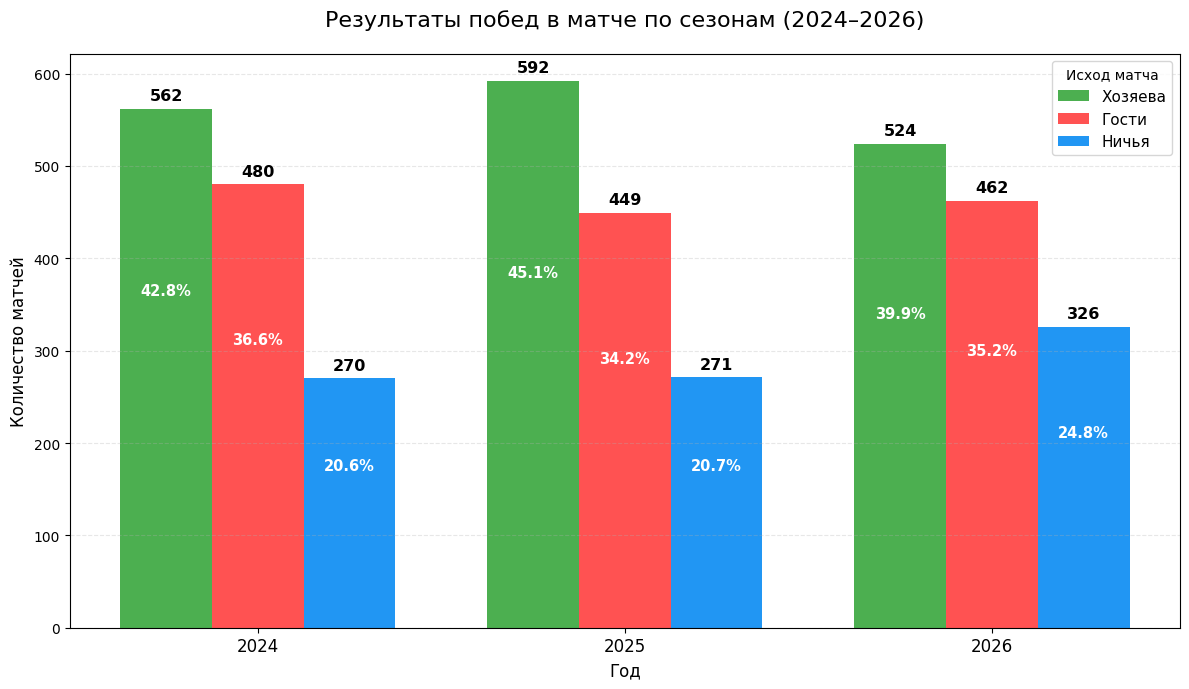

In [47]:
df24['Год'] = 2024
df25['Год'] = 2025
df26['Год'] = 2026
df = pd.concat([df24, df25, df26], ignore_index=True)

data = df.groupby(['Год', 'Кто победил']).size().unstack(fill_value=0)

order = [1, 2, 3]
labels = ['Хозяева', 'Гости', 'Ничья']
years = [2024, 2025, 2026]

data = data.reindex(index=years, columns=order).fillna(0)

# === График ===
x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(12, 7))

colors = ['#4CAF50', '#FF5252', '#2196F3']

for i, (result, color) in enumerate(zip(order, colors)):
    plt.bar(x + (i-1)*width, data[result], width=width, 
            label=labels[i], color=color)

plt.title('Результаты побед в матче по сезонам (2024–2026)', fontsize=16, pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество матчей', fontsize=12)
plt.xticks(x, years, fontsize=12)
plt.legend(title='Исход матча', fontsize=11)

# === Проценты внутри столбцов + количество сверху ===
total_per_year = data.sum(axis=1)

for i, result in enumerate(order):
    for j in range(len(years)):
        height = data.iloc[j, i]
        if height > 0:
            percentage = (height / total_per_year.iloc[j]) * 100
            
            # Процент внутри столбца (ближе к верху)
            plt.text(x[j] + (i-1)*width, height * 0.65, 
                     f'{percentage:.1f}%', 
                     ha='center', va='center', 
                     fontsize=10.5, fontweight='bold', color='white')
            
            # Количество сверху столбца
            plt.text(x[j] + (i-1)*width, height + 6, 
                     str(int(height)), 
                     ha='center', va='bottom', 
                     fontsize=11.5, fontweight='bold', color='black')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
df26.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1312 entries, 0 to 1311
Data columns (total 48 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Дата             1312 non-null   datetime64[ns]
 1   Хозяева          1312 non-null   object        
 2   Гости            1312 non-null   object        
 3   Состав1          1312 non-null   float64       
 4   Состав2          1312 non-null   float64       
 5   Игрок1           1261 non-null   object        
 6   Игрок2           1255 non-null   object        
 7   Счет1            1312 non-null   int64         
 8   Счет2            1312 non-null   int64         
 9   Ничья            326 non-null    float64       
 10  П1               1312 non-null   float64       
 11  X                1312 non-null   float64       
 12  П2               1312 non-null   float64       
 13  Кто победил      1312 non-null   int64         
 14  Угадали или нет  1312 non-null   int64  

In [18]:
#пропуски

df26.isna().sum()

Дата                 0
Хозяева              0
Гости                0
Состав1              0
Состав2              0
Игрок1              51
Игрок2              57
Счет1                0
Счет2                0
Ничья              986
П1                   0
X                    0
П2                   0
Кто победил          0
Угадали или нет      0
Серия                0
Штр. Время Хоз       0
Штр. Время Гос       0
ШБХ                  0
ШБГ                  0
ППХ                  0
ППГ                  0
ПКХ                  0
ПКГ                  0
Броски1              0
Броски2              0
Реал Бр Х            0
Реал Бр Г            0
Силовые1             0
Силовые2             0
Вбрасывания1         0
Вбрасывания2         0
Вбрасывания          0
Потери1              0
Потери2              0
Перехваты1           0
Перехваты2           0
Сила1                0
Сила2                0
Вратарь1             0
Вратарь2             0
Форма1              17
Форма2              15
Стоимость1 

In [19]:
# дубликаты

print('Дубликатов =', df26.duplicated().sum())

Дубликатов = 0


#Вратари

У каждой команды от одного до четырех вратарей, разделяем вратарей на основного (1), запасного (2) и резервного (3).

In [20]:
mapping = {
    # Основной вратарь - код 1
    'Веджвуд': 1,
    'Оттингер': 1,
    'Густавссон': 1,
    'Достал': 1,
    'Шмид': 1,
    'Джарри': 1,
    'Куемпер': 1,
    'Веймелка': 1,
    'Аскаров': 1,
    'Биннингтон': 1,
    'Хофер': 1,
    'Сарос': 1,
    'Вольф': 1,
    'Хеллебайк': 1,
    'Ланкинен': 1,
    'Даккор': 1,
    'Найт': 1,
    'Бусси': 1,
    'Андерсен': 1,
    'Гибсон': 1,
    'Талбот': 1,
    'Томпсон': 1,
    'Добес': 1,
    'Сорокин': 1,
    'Владар': 1,
    'Василевский': 1,
    'Аллен': 1,
    'Маркстрём': 1,
    'Свэймэн': 1,
    'Бобровский': 1,
    'Уллмарк': 1,
    'Шестеркин': 1,
    'Скиннер': 1,
    'Лайон': 1,
    'Хилдеби': 1,
    'Столарс': 1,
    'Гривз': 1,
    'Валисевский': 1,
    'Бобровский': 1,

    # Запасной вратарь - код 2
    'Блэквуд': 2,
    'Десмит': 2,
    'Уоллстедт': 2,
    'Мразек': 2,
    'Хуссо': 2,
    'Линдбом': 2,
    'Харт': 2,
    'Хилл': 2,
    'Пикар': 2,
    'Форсберг': 2,
    'Ванечек': 2,
    'Неделькович': 2,
    'Аннунен': 2,
    'Кули': 2,
    'Комри': 2,
    'Демко': 2,
    'Грубауэр': 2,
    'Мюррей': 2,
    'Седерблум': 2,
    'Кочетков': 2,
    'Линдгрен': 2,
    'Монтембо': 2,
    'Риттич': 2,
    'Эрссон': 2,
    'Йоханссон': 2,
    'Корписало': 2,
    'Тарасов': 2,
    'Мерилайнен': 2,
    'Куик': 2,
    'Шилов': 2,
    'Луукконен': 2,
    'Эллис': 2,
    'Уолл': 2,
    'Примо': 2,
    'Мерзликин': 2,
    
    # Резервный вратарь - код 3
    'Сергеев': 3,
    'Кокко': 3,
    'Ахтямов': 3,
    'Остман': 3,
    'Ингрэм': 3,
    'Патера': 3,
    'Комессо': 3,
    'Копли': 3,
    'Толопило': 3,
    'Раймер': 3,
    'Фовиер': 3,
    'Броссуа': 3,
    'Колосов': 3,
    'Милич': 3,
    'Коммессо': 3,
    'Мартин': 3,
    'Минер': 3,
    'Халверсон': 3,
    'Доус': 3,
    'Сёгаард': 3,
    'Стивенсон': 3,
    'Гаранд': 3,
    'Мурашов': 3,

}
# Теперь применяем к DataFrame
df26['Вратарь3'] = df26['Вратарь1'].map(mapping).fillna(0).astype(int)
df26['Вратарь4'] = df26['Вратарь2'].map(mapping).fillna(0).astype(int)

#Подсчет очков

Делаем автоматический подсчет очков по результату матча:
- Победа = 2 очка
- Поражение = 0 очков
- Победа ОТ = 2 очка
- Поражение ОТ = 1 очко

In [21]:
def calculate_ochki1(row):
    
    
    # Сравниваем счёт1 и счёт2
    if row['Счет1'] > row['Счет2']:
        return 2
    elif row['Счет1'] < row['Счет2']:
        return 0
    else:
        # Если счёт равный — смотрим колонку "ничья"
        nichya = row['Ничья']
        # На случай, если в колонке значения могут быть и строкой "1"/"2", и числом 1/2
        if nichya in [1, '1']:
            return 2
        elif nichya in [2, '2']:
            return 1
        else:
            # На всякий случай (если ничья не заполнена или другое значение)
            return 0


# Создаём новую колонку, проходя по каждой строке
df26['Очки1'] = df26.apply(calculate_ochki1, axis=1)


# Результат
print(df26[['Хозяева', 'Счет1', 'Счет2', 'Ничья', 'Очки1']].head())

        Хозяева  Счет1  Счет2  Ничья  Очки1
0       Флорида      3      2    NaN      2
1     Рейнджерс      0      3    NaN      0
2  Лос-Анджелес      1      4    NaN      0
3       Торонто      5      2    NaN      2
4     Вашингтон      1      3    NaN      0


In [22]:
def calculate_ochki2(row):
    # Сравниваем счёт1 и счёт2
    if row['Счет1'] > row['Счет2']:
        return 0
    elif row['Счет1'] < row['Счет2']:
        return 2
    else:
        # Если счёт равный — смотрим колонку "ничья"
        nichya = row['Ничья']
        # На случай, если в колонке значения могут быть и строкой "1"/"2", и числом 1/2
        if nichya in [1, '1']:
            return 1
        elif nichya in [2, '2']:
            return 2
        else:
            # На всякий случай (если ничья не заполнена или другое значение)
            return 0


# Создаём новую колонку, проходя по каждой строке
df26['Очки2'] = df26.apply(calculate_ochki2, axis=1)


# Результат
print(df26[['Гости', 'Счет1', 'Счет2', 'Ничья', 'Очки2']].head())

       Гости  Счет1  Счет2  Ничья  Очки2
0     Чикаго      3      2    NaN      0
1  Питтсбург      0      3    NaN      2
2   Колорадо      1      4    NaN      2
3   Монреаль      5      2    NaN      0
4     Бостон      1      3    NaN      2


In [23]:
df26 = df26.sort_index()  # на всякий случай сохраняем исходный порядок


df26['матч_номер_дома1'] = df26.groupby('Хозяева').cumcount() + 1
df26['Очки1_накоп'] = df26.groupby('Хозяева')['Очки1'].cumsum()


print(df26[['Хозяева', 'матч_номер_дома1', 'Очки1', 'Очки1_накоп']])

           Хозяева  матч_номер_дома1  Очки1  Очки1_накоп
0          Флорида                 1      2            2
1        Рейнджерс                 1      0            0
2     Лос-Анджелес                 1      0            0
3          Торонто                 1      2            2
4        Вашингтон                 1      0            0
...            ...               ...    ...          ...
1307       Нэшвилл                41      0           45
1308           Юта                41      0           47
1309       Калгари                41      2           51
1310      Эдмонтон                41      2           49
1311      Колорадо                41      2           58

[1312 rows x 4 columns]


In [24]:
df26 = df26.sort_index()  # на всякий случай сохраняем исходный порядок


df26['матч_номер_дома2'] = df26.groupby('Гости').cumcount() + 1
df26['Очки2_накоп'] = df26.groupby('Гости')['Очки2'].cumsum()


print(df26[['Гости', 'матч_номер_дома2', 'Очки2', 'Очки2_накоп']])

             Гости  матч_номер_дома2  Очки2  Очки2_накоп
0           Чикаго                 1      0            0
1        Питтсбург                 1      2            2
2         Колорадо                 1      2            2
3         Монреаль                 1      0            0
4           Бостон                 1      2            2
...            ...               ...    ...          ...
1307       Анахайм                41      2           40
1308     Сент-Луис                41      2           39
1309  Лос-Анджелес                41      0           51
1310      Ванкувер                41      0           35
1311         Сиэтл                41      0           36

[1312 rows x 4 columns]


#Подсчет серии Д-Г

У каждой команды идёт серия домашних и гостевых матчей. Допустим три домашних, затем два гостевых. В результате у команды будет серия: Д1 Д2 Д3 Г1 Г2

In [25]:
from collections import defaultdict


home_streak = defaultdict(int)   # серия домашних матчей
away_streak = defaultdict(int)   # серия гостевых матчей


result_column = []


for _, row in df26.iterrows():
    хозяин = row['Хозяева']
    гость = row['Гости']


    # Домашняя серия
    номер_дома = home_streak[хозяин] + 1
    home_streak[хозяин] = номер_дома
    away_streak[хозяин] = 0


    # Гостевая серия
    номер_в_гостях = away_streak[гость] + 1
    away_streak[гость] = номер_в_гостях
    home_streak[гость] = 0


    # Формируем строку в формате "Д2-Г1"
    combined = f"Д{номер_дома}-Г{номер_в_гостях}"
    result_column.append(combined)


# Добавляем новую колонку
df26['Match_Number'] = result_column

#ФОРМА В-П-В

В зависимости от результата матча команде присваивается статус, при выигрыше "В", при проигрыше "П", при ничьей "ВО" или "ПО". Данные накапливаются в колонке "Форма 1\2"

In [26]:
# Создаём колонки
df['Форма1'] = ''
df['Форма2'] = ''


# Словарь для накопления формы (последний матч будет в начале)
team_forms = defaultdict(list)   # используем список, чтобы потом легко соединять


for idx, row in df.iterrows():
    home = row['Хозяева']
    guest = row['Гости']
    score1 = row['Счет1']
    score2 = row['Счет2']
    nichya = row.get('Ничья', 0)


    # Определяем результат текущего матча (в верхнем регистре)
    if score1 > score2:
        result_home = 'В'
        result_guest = 'П'
    elif score1 < score2:
        result_home = 'П'
        result_guest = 'В'
    else:
        # Ничья / овертайм
        if str(nichya).strip() in ['1', '1.0', 1]:
            result_home = 'ВО'
            result_guest = 'ПО'
        else:
            result_home = 'ПО'
            result_guest = 'ВО'


    # Записываем предыдущую форму в колонки (разделённую "-") 
    current_form_home = '-'.join(team_forms[home]) if team_forms[home] else ''
    current_form_guest = '-'.join(team_forms[guest]) if team_forms[guest] else ''


    df.at[idx, 'Форма1'] = current_form_home
    df.at[idx, 'Форма2'] = current_form_guest


    # Добавляем результат текущего матча в начало списка
    team_forms[home].insert(0, result_home)
    team_forms[guest].insert(0, result_guest)

#Интеграция колонок "ничья"

Добавляем колонку "ничья" в датасет. А также накапливаем количество ничьих за пройденные матчей. И высчитываем количество матчей до ничьей, при наступлении ничьей результат обнуляется.

In [27]:
# Определяем, была ли ничья в матче
df26['Is_Draw'] = df26['Ничья'].notna() & df26['Ничья'].isin([1, 2])


# LONG FORMAT
home = df26[['Дата', 'Хозяева', 'Is_Draw']].rename(columns={'Хозяева': 'Team'}).copy()
away = df26[['Дата', 'Гости',   'Is_Draw']].rename(columns={'Гости': 'Team'}).copy()


long = pd.concat([home, away], ignore_index=True)
long = long.sort_values(by=['Team', 'Дата']).reset_index(drop=True)


#  ДВЕ ОТДЕЛЬНЫЕ ФУНКЦИИ
def calculate_streak(group):
    """Расчёт текущей серии без ничьих (начинается с 0)"""
    streak = 0
    result = []
    for is_draw in group:
        result.append(streak)          # записываем значение до обновления
        if is_draw:
            streak = 0
        else:
            streak += 1
    return result


def calculate_max_streak(group):
    """Расчёт максимальной серии без ничьих за всё время"""
    current = 0
    max_streak = 0
    result = []
    for is_draw in group:
        if is_draw:
            current = 0
        else:
            current += 1
        max_streak = max(max_streak, current)
        result.append(max_streak)
    return result


# Применяем функции
long['Streak'] = long.groupby('Team')['Is_Draw'].transform(calculate_streak)
long['Max_Streak'] = long.groupby('Team')['Is_Draw'].transform(calculate_max_streak)


#  Перенос обратно в df
streak_map = long.set_index(['Дата', 'Team'])['Streak'].to_dict()
max_map = long.set_index(['Дата', 'Team'])['Max_Streak'].to_dict()


df26['Streak_Хозяева']     = df26.apply(lambda r: streak_map.get((r['Дата'], r['Хозяева']), 0), axis=1)
df26['Streak_Гости']       = df26.apply(lambda r: streak_map.get((r['Дата'], r['Гости']),   0), axis=1)


df26['Max_Streak_Хозяева'] = df26.apply(lambda r: max_map.get((r['Дата'], r['Хозяева']), 0), axis=1)
df26['Max_Streak_Гости']   = df26.apply(lambda r: max_map.get((r['Дата'], r['Гости']),   0), axis=1)


# Удаляем временную колонку
df26 = df26.drop(columns=['Is_Draw'])

#Среднее количество шайб

In [28]:
average_df = df26.groupby('Хозяева', as_index=False).agg(ШХ=('Счет1', 'mean'))
average_df1 = df26.groupby('Гости', as_index=False).agg(ШГ=('Счет2', 'mean'))
df26 = pd.merge(df26, average_df, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df1, on='Гости', how='left')

In [29]:
average_df = df26.groupby('Хозяева', as_index=False).agg(ПШХ=('Счет2', 'mean'))
average_df1 = df26.groupby('Гости', as_index=False).agg(ПШГ=('Счет1', 'mean'))
df26 = pd.merge(df26, average_df, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df1, on='Гости', how='left')

#Среднее Штрафное время

In [30]:
average_df2 = df26.groupby('Хозяева', as_index=False).agg(Ср_Штраф_Х=('Штр. Время Хоз', 'mean'))
average_df3 = df26.groupby('Гости', as_index=False).agg(СР_Штраф_Г=('Штр. Время Гос', 'mean'))
df26 = pd.merge(df26, average_df2, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df3, on='Гости', how='left')

#Среднее количество бросков

In [31]:
average_df3 = df26.groupby('Хозяева', as_index=False).agg(Ср_Броски_Х=('Броски1', 'mean'))
average_df4 = df26.groupby('Гости', as_index=False).agg(СР_Броски_Г=('Броски2', 'mean'))
df26 = pd.merge(df26, average_df3, on='Хозяева', how='left')
df26 = pd.merge(df26, average_df4, on='Гости', how='left')

In [32]:
df26

,Дата,Хозяева,Гости,Состав1,Состав2,Игрок1,Игрок2,Счет1,Счет2,Ничья,...,Max_Streak_Хозяева,Max_Streak_Гости,ШХ,ШГ,ПШХ,ПШГ,Ср_Штраф_Х,СР_Штраф_Г,Ср_Броски_Х,СР_Броски_Г
0,2025-10-08,Флорида,Чикаго,0.00,-0.50,"Barkov A., Nosek T., Tkachuk M.","Brossoit L., Slaggert L., Vlasic A., Weber S.",3,2,NaN,...,1,1,3.097561,2.487805,2.926829,3.268293,3.170732,2.731707,30.024390,24.926829
1,2025-10-08,Рейнджерс,Питтсбург,0.00,-1.00,NaN,"Blomqvist J., Hayes K., McGroarty R., Rust B.,...",0,3,NaN,...,1,1,2.463415,3.414634,2.853659,2.853659,2.731707,2.609756,24.853659,28.439024
2,2025-10-08,Лос-Анджелес,Колорадо,0.00,0.00,"Burroughs K., Perry C.","Blackwood M., O'Connor L.",1,4,NaN,...,1,1,2.512195,3.390244,2.902439,2.195122,2.609756,2.926829,28.536585,32.268293
3,2025-10-09,Торонто,Монреаль,0.00,0.00,Woll J.,NaN,5,2,NaN,...,1,1,3.219512,3.390244,3.341463,2.951220,2.707317,3.243902,26.512195,25.707317
4,2025-10-09,Вашингтон,Бостон,0.00,0.00,McIlrath D.,NaN,1,3,NaN,...,1,1,3.317073,2.951220,2.536585,3.317073,2.780488,3.707317,28.926829,26.682927
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1307,2026-04-17,Нэшвилл,Анахайм,-3.25,-0.50,"Hague N., Haula E., Josi R., Marchessault J.","Gudas R., Harkins J., Johnston R., Mrazek P.",4,5,NaN,...,7,6,2.975610,2.926829,3.146341,3.487805,3.243902,3.341463,27.292683,30.292683
1308,2026-04-17,Юта,Сент-Луис,-3.25,0.00,"Durzi S., Guenther D., Hayton B., McBain J.",Krug T.,3,5,NaN,...,13,11,3.219512,2.780488,2.951220,3.097561,3.024390,2.902439,28.682927,25.804878
1309,2026-04-17,Калгари,Лос-Анджелес,-1.50,-1.75,"Bahl K., Bean J., Cooley D., Hanley J., Honzek...","Fiala K., Kuzmenko A., Malott J., Turcotte A.",3,1,NaN,...,9,8,2.829268,2.658537,2.512195,2.634146,2.634146,3.073171,28.731707,27.439024
1310,2026-04-17,Эдмонтон,Ванкувер,-2.25,-0.75,"Dickinson J., Draisaitl L., Janmark M., Jones M.","Chytil F., Demko T., Forbort D., Kane E., Lekk...",6,1,NaN,...,14,13,3.390244,2.634146,3.317073,3.731707,2.731707,2.804878,30.878049,24.707317


In [ ]:
df26.to_excel('df26.xlsx', index=False)

In [33]:
value_counts = df26['Серия'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Серия': {count} ({percentage:.2f}%)")

Количество значений 'Д1-Г1' в столбце 'Серия': 259 (19.74%)
Количество значений 'Д2-Г1' в столбце 'Серия': 150 (11.43%)
Количество значений 'Д1-Г2' в столбце 'Серия': 137 (10.44%)
Количество значений 'Д2-Г2' в столбце 'Серия': 95 (7.24%)
Количество значений 'Д1-Г3' в столбце 'Серия': 83 (6.33%)
Количество значений 'Д3-Г1' в столбце 'Серия': 69 (5.26%)
Количество значений 'Д2-Г3' в столбце 'Серия': 58 (4.42%)
Количество значений 'Д3-Г2' в столбце 'Серия': 48 (3.66%)
Количество значений 'Д1-Г4' в столбце 'Серия': 46 (3.51%)
Количество значений 'Д4-Г1' в столбце 'Серия': 37 (2.82%)
Количество значений 'Д3-Г3' в столбце 'Серия': 35 (2.67%)
Количество значений 'Д4-Г2' в столбце 'Серия': 30 (2.29%)
Количество значений 'Д1-Г5' в столбце 'Серия': 27 (2.06%)
Количество значений 'Д2-Г4' в столбце 'Серия': 27 (2.06%)
Количество значений 'Д3-Г4' в столбце 'Серия': 22 (1.68%)
Количество значений 'Д4-Г4' в столбце 'Серия': 18 (1.37%)
Количество значений 'Д5-Г1' в столбце 'Серия': 18 (1.37%)
Количест

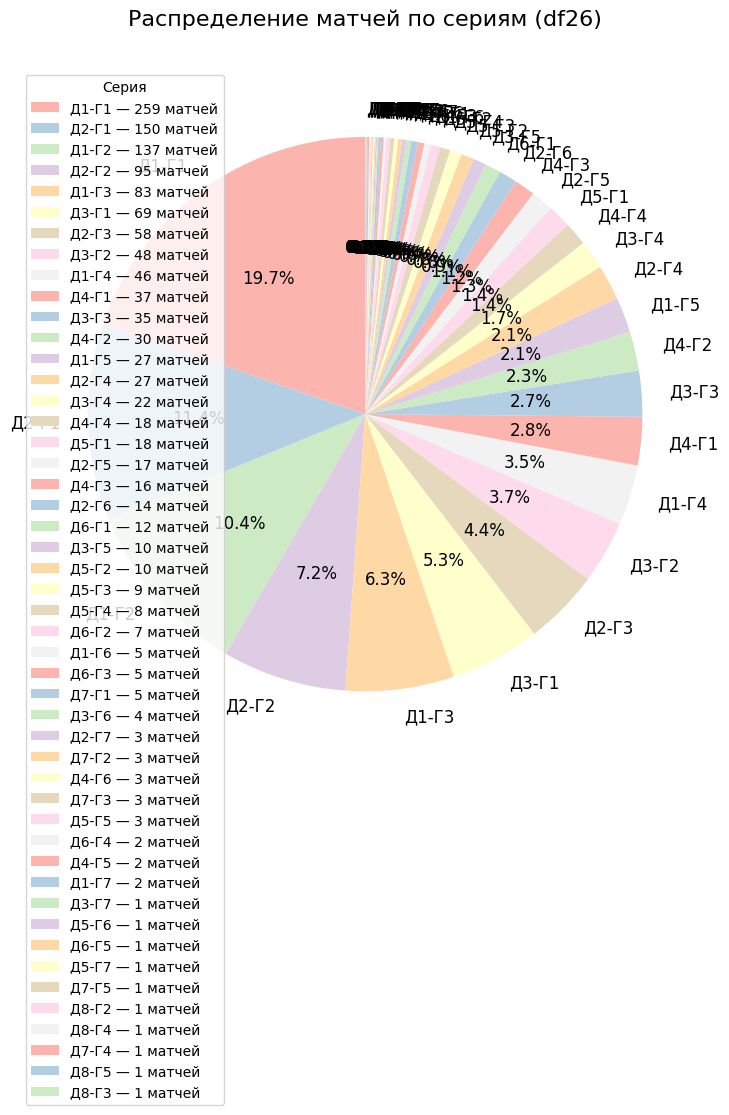

In [34]:
plt.figure(figsize=(9, 9))

plt.pie(value_counts.values, 
        labels=value_counts.index.astype(str),
        autopct='%1.1f%%',
        startangle=90,
        colors=plt.cm.Pastel1.colors,
        textprops={'fontsize': 12})

plt.title('Распределение матчей по сериям (df26)', fontsize=16, pad=30)

# Добавляем легенду с абсолютными значениями
legend_labels = [f'{val} — {count} матчей' 
                 for val, count in zip(value_counts.index, value_counts.values)]
plt.legend(legend_labels, title='Серия', loc='best')

plt.show()

In [35]:
# Базовая таблица
table = pd.crosstab(df26['Серия'], df26['Кто победил'])

# Добавляем проценты по строкам
table_percent = pd.crosstab(df26['Серия'], df26['Кто победил'], 
                           normalize='index') * 100

# Объединяем в одну красивую таблицу
result = table.astype(str) + " (" + table_percent.round(1).astype(str) + "%)"

# Переименовываем столбцы
result.columns = ['Хозяева (1)', 'Гости (2)', 'Ничья (3)']

print("Количество и процент по сериям:")
display(result)

Количество и процент по сериям:


,Хозяева (1),Гости (2),Ничья (3)
Серия,,,
Д1-Г1,113 (43.6%),92 (35.5%),54 (20.8%)
Д1-Г2,57 (41.6%),42 (30.7%),38 (27.7%)
Д1-Г3,23 (27.7%),38 (45.8%),22 (26.5%)
Д1-Г4,20 (43.5%),15 (32.6%),11 (23.9%)
Д1-Г5,14 (51.9%),8 (29.6%),5 (18.5%)
Д1-Г6,0 (0.0%),3 (60.0%),2 (40.0%)
Д1-Г7,0 (0.0%),1 (50.0%),1 (50.0%)
Д2-Г1,55 (36.7%),50 (33.3%),45 (30.0%)
Д2-Г2,40 (42.1%),31 (32.6%),24 (25.3%)


Среднее количество шайб

In [42]:
# Группировка по домашним матчам
home_stats = df26.groupby('Хозяева').agg(
    ШХ_дома_avg=('ШХ', 'mean'),      # среднее забитых дома
    ПШХ_дома_avg=('ПШХ', 'mean'),    # среднее пропущенных дома
    Матчи_дома=('Хозяева', 'count')
).reset_index()

# Группировка по гостевым матчам
away_stats = df26.groupby('Гости').agg(
    ШГ_гости_avg=('ШГ', 'mean'),     # среднее забитых в гостях
    ПШГ_гости_avg=('ПШГ', 'mean'),   # среднее пропущенных в гостях
    Матчи_гости=('Гости', 'count')
).reset_index()

# Объединяем в одну таблицу
comparison = home_stats.merge(
    away_stats, 
    left_on='Хозяева', 
    right_on='Гости', 
    how='outer'
)

# Приводим в порядок
comparison = comparison.rename(columns={'Хозяева': 'Команда'})
comparison = comparison.drop(columns=['Гости'], errors='ignore')

# Округляем до 2 знаков после запятой
comparison = comparison.round(2)

# Порядок колонок
cols = ['Команда', 
        'ШХ_дома_avg', 'ПШХ_дома_avg', 
        'ШГ_гости_avg', 'ПШГ_гости_avg',]

comparison = comparison[cols]

# Сортировка по алфавиту команд
comparison = comparison.sort_values('Команда').reset_index(drop=True)

print(comparison)
comparison.to_csv('team_comparison_avg.csv', index=False)

         Команда  ШХ_дома_avg  ПШХ_дома_avg  ШГ_гости_avg  ПШГ_гости_avg
0      Айлендерс         2.80          2.93          2.54           2.83
1        Анахайм         3.32          3.39          2.93           3.49
2        Баффало         3.54          2.78          3.29           2.88
3         Бостон         3.39          2.54          2.95           3.32
4       Ванкувер         2.39          3.78          2.63           3.73
5      Вашингтон         3.32          2.54          2.95           3.20
6          Вегас         3.51          2.88          2.73           2.80
7       Виннипег         2.98          2.95          2.49           3.10
8         Даллас         3.12          2.63          3.41           2.61
9        Детройт         2.93          3.24          2.68           2.80
10       Калгари         2.83          2.51          2.20           3.61
11      Каролина         3.71          3.02          3.17           2.66
12      Коламбус         3.22          2.88        

#Угадали или нет

In [51]:
value_counts = df24['Угадали или нет'].value_counts()

# Общее количество значений
total_count = len(df24)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Угадали или нет': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Угадали или нет': 649 (49.47%)
Количество значений '2' в столбце 'Угадали или нет': 393 (29.95%)
Количество значений '3' в столбце 'Угадали или нет': 270 (20.58%)


In [52]:
value_counts = df25['Угадали или нет'].value_counts()

# Общее количество значений
total_count = len(df25)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Угадали или нет': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Угадали или нет': 654 (49.85%)
Количество значений '2' в столбце 'Угадали или нет': 387 (29.50%)
Количество значений '3' в столбце 'Угадали или нет': 271 (20.66%)


In [53]:
value_counts = df26['Угадали или нет'].value_counts()

# Общее количество значений
total_count = len(df26)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Угадали или нет': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Угадали или нет': 561 (42.76%)
Количество значений '2' в столбце 'Угадали или нет': 425 (32.39%)
Количество значений '3' в столбце 'Угадали или нет': 326 (24.85%)


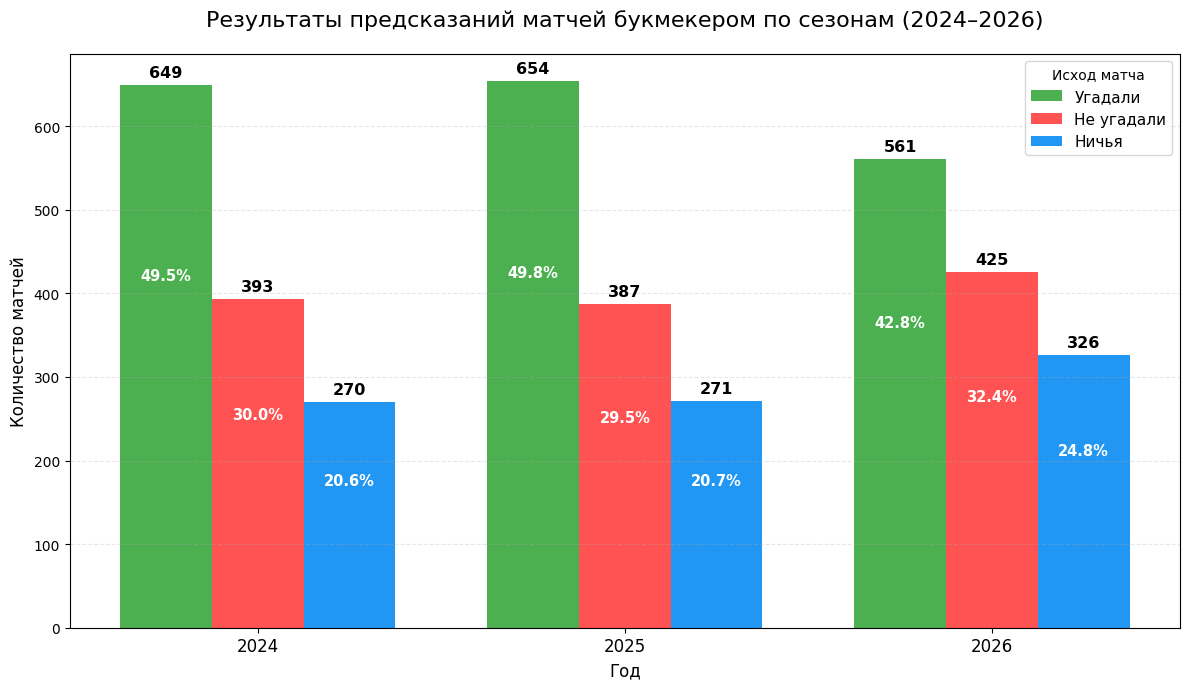

In [50]:
df24['Год'] = 2024
df25['Год'] = 2025
df26['Год'] = 2026
df = pd.concat([df24, df25, df26], ignore_index=True)

data = df.groupby(['Год', 'Угадали или нет']).size().unstack(fill_value=0)

order = [1, 2, 3]
labels = ['Угадали', 'Не угадали', 'Ничья']
years = [2024, 2025, 2026]

data = data.reindex(index=years, columns=order).fillna(0)

# === График ===
x = np.arange(len(years))
width = 0.25

plt.figure(figsize=(12, 7))

colors = ['#4CAF50', '#FF5252', '#2196F3']

for i, (result, color) in enumerate(zip(order, colors)):
    plt.bar(x + (i-1)*width, data[result], width=width, 
            label=labels[i], color=color)

plt.title('Результаты предсказаний матчей букмекером по сезонам (2024–2026)', fontsize=16, pad=20)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество матчей', fontsize=12)
plt.xticks(x, years, fontsize=12)
plt.legend(title='Исход матча', fontsize=11)

# === Проценты внутри столбцов + количество сверху ===
total_per_year = data.sum(axis=1)

for i, result in enumerate(order):
    for j in range(len(years)):
        height = data.iloc[j, i]
        if height > 0:
            percentage = (height / total_per_year.iloc[j]) * 100
            
            # Процент внутри столбца (ближе к верху)
            plt.text(x[j] + (i-1)*width, height * 0.65, 
                     f'{percentage:.1f}%', 
                     ha='center', va='center', 
                     fontsize=10.5, fontweight='bold', color='white')
            
            # Количество сверху столбца
            plt.text(x[j] + (i-1)*width, height + 6, 
                     str(int(height)), 
                     ha='center', va='bottom', 
                     fontsize=11.5, fontweight='bold', color='black')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#Среднее значение по кэфам

In [54]:
average_score1 = df24['П1'].mean()
average_score2 = df24['X'].mean()
average_score3 = df24['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score1:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score2:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score3:.2f}")

Среднее значение по столбцу 'П1': 2.45
Среднее значение по столбцу 'X': 4.64
Среднее значение по столбцу 'П2': 2.92


In [55]:
average_score1 = df25['П1'].mean()
average_score2 = df25['X'].mean()
average_score3 = df25['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score1:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score2:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score3:.2f}")

Среднее значение по столбцу 'П1': 2.43
Среднее значение по столбцу 'X': 4.52
Среднее значение по столбцу 'П2': 2.94


#Фильтр победа фаворита дома

In [56]:
# Фильтрация строк
filtered_df26 = df26[(df26['Кто победил'] == 1) & (df26['Угадали или нет'] == 1)]
# Вывод результата
#print(filtered_df26)

In [57]:
count = filtered_df26.shape[0]  # или len(filtered_df26)
print(count)

378


In [58]:
average_score3 = filtered_df26['П1'].mean()
average_score4 = filtered_df26['X'].mean()
average_score5 = filtered_df26['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score3:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score4:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score5:.2f}")

Среднее значение по столбцу 'П1': 2.01
Среднее значение по столбцу 'X': 4.44
Среднее значение по столбцу 'П2': 3.24


# Фильтр победа сильных в гостях

In [61]:
# Фильтрация строк
filtered_df26 = df26[(df26['Кто победил'] == 2) & (df26['Угадали или нет'] == 1)]
#print(filtered_df26)

In [62]:
count = filtered_df26.shape[0]  # или len(filtered_df26)
print(count)

183


In [63]:
average_score6 = filtered_df26['П1'].mean()
average_score7 = filtered_df26['X'].mean()
average_score8 = filtered_df26['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score6:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score7:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score8:.2f}")

Среднее значение по столбцу 'П1': 2.94
Среднее значение по столбцу 'X': 4.37
Среднее значение по столбцу 'П2': 2.13


# Победа слабых в гостях

In [65]:
# Фильтрация строк
filtered_df26 = df24[(df24['Кто победил'] == 2) & (df24['Угадали или нет'] == 2)]

#Победа слабых дома

In [68]:
# Фильтрация строк
filtered_df24 = df24[(df24['Кто победил'] == 1) & (df24['Угадали или нет'] == 2)]

In [69]:
average_score12 = filtered_df24['П1'].mean()
average_score13 = filtered_df24['X'].mean()
average_score14 = filtered_df24['П2'].mean()

# Вывод результата
print(f"Среднее значение по столбцу 'П1': {average_score12:.2f}")
print(f"Среднее значение по столбцу 'X': {average_score13:.2f}")
print(f"Среднее значение по столбцу 'П2': {average_score14:.2f}")

Среднее значение по столбцу 'П1': 3.09
Среднее значение по столбцу 'X': 4.55
Среднее значение по столбцу 'П2': 2.10


#Сильные дома

In [71]:
result = df24[df24['Угадали или нет'] == 1]


In [73]:
value_counts = result['Кто победил'].value_counts()

# Общее количество значений
total_count = len(result)

# Вывод результатов с процентами
for value, count in value_counts.items():
    percentage = (count / total_count) * 100
    print(f"Количество значений '{value}' в столбце 'Кто победил': {count} ({percentage:.2f}%)")

Количество значений '1' в столбце 'Кто победил': 400 (61.63%)
Количество значений '2' в столбце 'Кто победил': 249 (38.37%)


#12

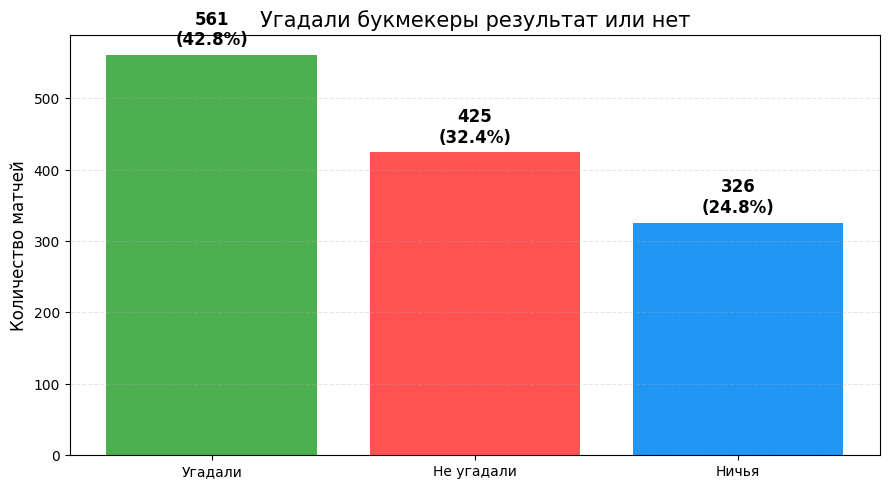

In [93]:
counts = df26['Угадали или нет'].value_counts().sort_index()

total = len(df26)

plt.figure(figsize=(9, 5))
bars = plt.bar(labels, counts, color=['#4CAF50', '#FF5252', '#2196F3'])

plt.title('Угадали букмекеры результат или нет', fontsize=15)
plt.ylabel('Количество матчей', fontsize=12)

for bar in bars:
    height = bar.get_height()
    percentage = (height / total) * 100
    plt.text(bar.get_x() + bar.get_width()/2., height + 8,
             f'{int(height)}\n({percentage:.1f}%)',
             ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

#2026

In [81]:
# Победа слабых дома

sh = df26[(df26['Кто победил'] == 1) & (df26['Угадали или нет'] == 2)]
# Вывод результата
#print(sh)

count = sh.shape[0]  # или len(sh)
print(count)

146


In [82]:
# Среднее значение по кэфу

average_score2 = sh['П1'].mean()

print(f"Среднее значение по столбцу 'П1': {average_score2:.2f}")

Среднее значение по столбцу 'П1': 2.82


##Победа в гостях

In [83]:
# Победа фаворита в гостях

fv = df26[(df26['Кто победил'] == 2) & (df26['Угадали или нет'] == 1)]
# Вывод результата
#print(fv)

count = fv.shape[0]  # или len(fv)
print(count)

183


In [84]:
# Среднее значение по кэфу

average_score3 = fv['П2'].mean()

print(f"Среднее значение по столбцу 'П2': {average_score3:.2f}")

Среднее значение по столбцу 'П2': 2.13


In [85]:
# Победа слабых в гостях

sv = df26[(df26['Кто победил'] == 2) & (df26['Угадали или нет'] == 2)]
# Вывод результата
#print(sv)

count = sv.shape[0]  # или len(sv)
print(count)

279


In [86]:
# Среднее значение по кэфу

average_score4 = sv['П2'].mean()

print(f"Среднее значение по столбцу 'П2': {average_score4:.2f}")

Среднее значение по столбцу 'П2': 2.99


## Ничья

In [87]:
Draw = df26[(df26['Кто победил'] == 3) & (df26['Угадали или нет'] == 3)]
# Вывод результата
#print(Draw)

count = Draw.shape[0]  # или len(Draw)
print(count)

326


In [88]:
# Среднее значение по кэфу

average_score5 = Draw['X'].mean()

print(f"Среднее значение по столбцу 'X': {average_score5:.2f}")

Среднее значение по столбцу 'X': 4.38
